In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

# Load the dataset
# data = load_breast_cancer()
# X = pd.DataFrame(data.data, columns=data.feature_names)
# y = data.target

In [13]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [15]:
print(f"Dataset Shape: {X.shape}")
print(f"Target Classes: {data.target_names}")

Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
baseline_rf = RandomForestClassifier(random_state=42)
baseline_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
y_pred_base = baseline_rf.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_f1 = f1_score(y_test, y_pred_base)
print(f"\nBaseline Accuracy: {baseline_acc:.4f}")


Baseline Accuracy: 0.9649


# Model Evaluation

In [19]:
cm = confusion_matrix(y_test, y_pred_base)

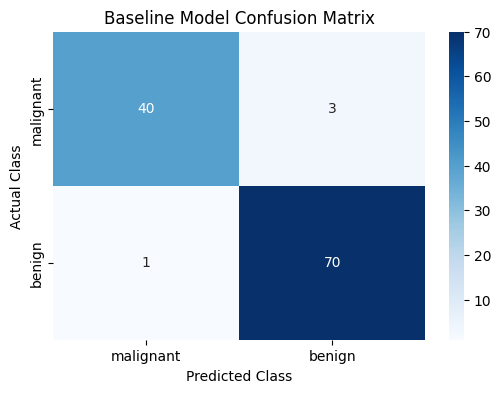

In [20]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Baseline Model Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

In [22]:
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred_base, target_names=data.target_names))

Detailed Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [24]:
cv_scores = cross_val_score(baseline_rf, X_train, y_train, cv=5, scoring='f1')

print(f"CV Scores for each fold: {cv_scores}")
print(f"Average CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

CV Scores for each fold: [0.98305085 0.95726496 0.98214286 0.96491228 0.94827586]
Average CV F1: 0.9671 (+/- 0.0274)


In [25]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1, # Use all available CPU cores
                           verbose=1)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters from Grid Search: {grid_search.best_params_}")
best_grid_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters from Grid Search: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [26]:
param_dist = {
    'n_estimators': np.arange(50, 500, 50),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': np.arange(2, 15, 2),
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                                   param_distributions=param_dist,
                                   n_iter=20,
                                   cv=3,
                                   n_jobs=-1,
                                   random_state=42,
                                   verbose=1)

random_search.fit(X_train, y_train)

print(f"\nBest Parameters from Random Search: {random_search.best_params_}")
best_random_model = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters from Random Search: {'n_estimators': np.int64(200), 'min_samples_split': np.int64(8), 'max_depth': None, 'bootstrap': False}


In [30]:
y_pred_grid = best_grid_model.predict(X_test)
y_pred_random = best_random_model.predict(X_test)

acc_grid = accuracy_score(y_test, y_pred_grid)
acc_random = accuracy_score(y_test, y_pred_random)
f1_grid = f1_score(y_test, y_pred_grid)
f1_random = accuracy_score(y_test, y_pred_random)

results = pd.DataFrame({
    'Model': ['Baseline', 'Grid Search Tuned', 'Random Search Tuned'],
    'Test Accuracy': [baseline_acc, acc_grid, acc_random],
    'Test F1': [baseline_acc, f1_grid, f1_random]
})

print("\n--- Final Model Comparison ---")
print(results.to_string(index=False))


--- Final Model Comparison ---
              Model  Test Accuracy  Test F1
           Baseline       0.964912 0.964912
  Grid Search Tuned       0.964912 0.972222
Random Search Tuned       0.964912 0.964912
